## DML

"유저/아이템 특성을 통제했을 때, '노출' 자체가 watch_ratio에 미치는 평균 인과효과는?"

$$ Y(u,i)=\theta \cdot T(u,i) + g(X_u​,X_i​) + \epsilon $$

- $T$ : 노출 확률 (또는 노출 강도)

- $X_u,X_i$: 유저/아이템 특성

- $\theta$: 우리가 알고 싶은 인과효과

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
import time

DATA_DIR = "KuaiRec/data"

big = pd.read_csv(f"{DATA_DIR}/big_matrix.csv")
small = pd.read_csv(f"{DATA_DIR}/small_matrix.csv")
user_features = pd.read_csv(f"{DATA_DIR}/user_features.csv")
item_daily = pd.read_csv(f"{DATA_DIR}/item_daily_features.csv")

print(f"big: {big.shape} | user_features: {user_features.shape} | item_daily: {item_daily.shape}")

big: (12530806, 8) | user_features: (7176, 31) | item_daily: (343341, 58)


In [4]:
item_numeric = item_daily.select_dtypes(include=[np.number]).columns.tolist()
item_numeric = [c for c in item_numeric if c != 'video_id']

item_features_agg = item_daily.groupby("video_id")[item_numeric].mean().reset_index()
print(f"집약 후: {item_features_agg.shape}")

집약 후: (10728, 53)


In [5]:
exposure_count = big.groupby("video_id")["user_id"].nunique()
n_users_big = big["user_id"].nunique()
propensity = (exposure_count / n_users_big).clip(lower=0.05, upper=1.0)
print(f"Propensity: 평균 {propensity.mean():.3f}, 범위 [{propensity.min():.3f}, {propensity.max():.3f}]")

Propensity: 평균 0.156, 범위 [0.050, 0.748]


In [6]:
np.random.seed(42)
SAMPLE_SIZE = 500_000

big_sample = big.sample(n=min(SAMPLE_SIZE, len(big)), random_state=42).copy()
big_sample = big_sample.merge(propensity.rename("T_propensity").reset_index(), 
                               on="video_id", how="left")
big_sample = big_sample.merge(user_features, on="user_id", how="left")
big_sample = big_sample.merge(item_features_agg, on="video_id", how="left")

print(f"최종 shape: {big_sample.shape}")

최종 shape: (500000, 91)


In [7]:
exclude = {'user_id', 'video_id', 'time', 'date', 'timestamp', 
           'watch_ratio', 'play_duration', 'T_propensity',
           'upload_dt', 'upload_type'}

X_COLS = [c for c in big_sample.columns if c not in exclude]
print(f"X 차원: {len(X_COLS)}개")
print(f"샘플: {X_COLS[:10]}")

X 차원: 85개
샘플: ['play_duration_x', 'video_duration_x', 'date_x', 'user_active_degree', 'is_lowactive_period', 'is_live_streamer', 'is_video_author', 'follow_user_num_x', 'follow_user_num_range', 'fans_user_num']


### 전처리

In [8]:
df = big_sample[X_COLS + ['T_propensity', 'watch_ratio']].copy()

# Object → 숫자
for col in X_COLS:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category').cat.codes

# 무한대 + 결측 처리
df = df.replace([np.inf, -np.inf], np.nan)
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Watch_ratio 99% 클리핑 (이상치)
df['watch_ratio'] = df['watch_ratio'].clip(upper=df['watch_ratio'].quantile(0.99))

# 큰 카운트는 log
for col in df.columns:
    if col in X_COLS and df[col].max() > 1000:
        df[col] = np.log1p(df[col].clip(lower=0))

print(f"전처리 완료: {df.shape}")

X = df[X_COLS].values.astype(np.float32)
T = df['T_propensity'].values.astype(np.float32)
Y = df['watch_ratio'].values.astype(np.float32)

전처리 완료: (500000, 87)


### DML 함수

In [9]:
def dml(X, T, Y, n_folds=5, n_estimators=50, max_depth=8, verbose=True):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    T_residuals = np.zeros_like(T, dtype=float)
    Y_residuals = np.zeros_like(Y, dtype=float)
    fold_r2_T, fold_r2_Y = [], []
    
    for fold_idx, (tr, te) in enumerate(kf.split(X)):
        if verbose:
            print(f"  Fold {fold_idx+1}/{n_folds}...")
        
        # Stage 1: T ~ X
        m = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                   n_jobs=-1, random_state=42)
        m.fit(X[tr], T[tr])
        T_residuals[te] = T[te] - m.predict(X[te])
        fold_r2_T.append(m.score(X[te], T[te]))
        
        # Stage 2: Y ~ X
        l = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                   n_jobs=-1, random_state=42)
        l.fit(X[tr], Y[tr])
        Y_residuals[te] = Y[te] - l.predict(X[te])
        fold_r2_Y.append(l.score(X[te], Y[te]))
    
    # Stage 3: 잔차 회귀
    theta = (T_residuals * Y_residuals).sum() / (T_residuals**2).sum()
    
    # 표준오차
    psi = T_residuals * (Y_residuals - theta * T_residuals)
    n = len(X)
    se = np.sqrt((psi**2).mean() / (T_residuals**2).mean()**2 / n)
    
    return {
        'theta': theta, 'se': se,
        'ci_low': theta - 1.96*se, 'ci_high': theta + 1.96*se,
        'T_residuals': T_residuals, 'Y_residuals': Y_residuals,
        'r2_T': np.mean(fold_r2_T), 'r2_Y': np.mean(fold_r2_Y),
    }

DML 실행

공변량 영향이 제거된 노출의 순수 인과효과 θ 추정

In [10]:
print("DML 시작...")
start = time.time()
result = dml(X, T, Y, n_folds=5)
print(f"\n소요: {(time.time()-start)/60:.1f}분")

print(f"\nR² (T~X): {result['r2_T']:.3f}")
print(f"R² (Y~X): {result['r2_Y']:.3f}")
print(f"θ̂ = {result['theta']:.4f}")
print(f"SE = {result['se']:.4f}")
print(f"95% CI = [{result['ci_low']:.4f}, {result['ci_high']:.4f}]")
print(f"유의함? {'YES' if abs(result['theta']/result['se']) > 1.96 else 'NO'}")

DML 시작...
  Fold 1/5...
  Fold 2/5...
  Fold 3/5...
  Fold 4/5...
  Fold 5/5...

소요: 12.7분

R² (T~X): 0.601
R² (Y~X): 0.997
θ̂ = 0.0058
SE = 0.0006
95% CI = [0.0047, 0.0070]
유의함? YES


### Naive (X 통제 안 한 단순 회귀) vs DML

Naive θ: -0.0683
DML   θ: 0.0058
차이: -0.0741 (과대추정 → DML로 보정됨)


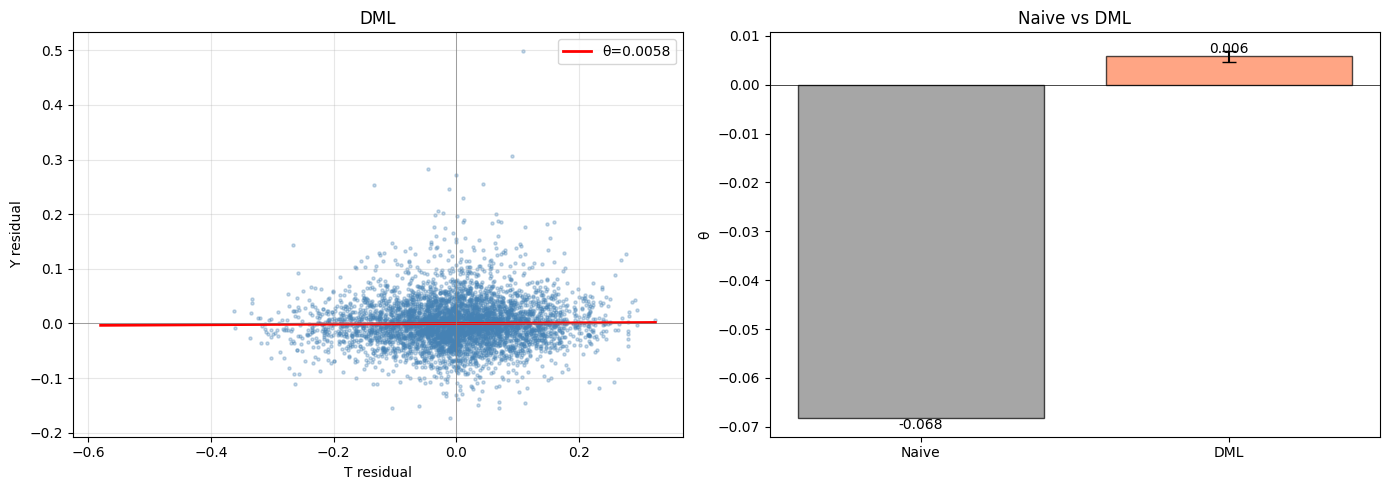

In [12]:
naive_theta = np.cov(T, Y, ddof=1)[0, 1] / np.var(T, ddof=1)

print(f"Naive θ: {naive_theta:.4f}")
print(f"DML   θ: {result['theta']:.4f}")
print(f"차이: {naive_theta - result['theta']:.4f} "
      f"({'과대추정' if abs(naive_theta) > abs(result['theta']) else '과소추정'} → DML로 보정됨)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 잔차 산점도
T_res, Y_res = result['T_residuals'], result['Y_residuals']
idx = np.random.choice(len(T_res), size=min(5000, len(T_res)), replace=False)
axes[0].scatter(T_res[idx], Y_res[idx], alpha=0.3, s=5, color='steelblue')
t_line = np.linspace(T_res.min(), T_res.max(), 100)
axes[0].plot(t_line, result['theta']*t_line, 'r-', lw=2, 
             label=f'θ={result["theta"]:.4f}')
axes[0].axhline(0, color='gray', lw=0.5)
axes[0].axvline(0, color='gray', lw=0.5)
axes[0].set_xlabel("T residual"); axes[0].set_ylabel("Y residual")
axes[0].set_title("DML"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Naive vs DML
methods = ['Naive', 'DML']
estimates = [naive_theta, result['theta']]
bars = axes[1].bar(methods, estimates, color=['gray', 'coral'], 
                    alpha=0.7, edgecolor='black')
axes[1].errorbar([1], [result['theta']], 
                  yerr=[[1.96*result['se']], [1.96*result['se']]],
                  fmt='none', color='black', capsize=5)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_ylabel("θ"); axes[1].set_title("Naive vs DML")
for bar, val in zip(bars, estimates):
    axes[1].text(bar.get_x()+bar.get_width()/2, val, f'{val:.3f}',
                 ha='center', va='bottom' if val > 0 else 'top')

plt.tight_layout()
plt.show()

- θ ≈ 0

- ê_T와 ê_Y가 거의 무관함

Naive 회귀: "노출 확률(propensity)이 높은 아이템일수록 watch_ratio가 낮다" — 음의 상관

confounding

| 인기 아이템 (높은 propensity) | 비인기 아이템 (낮은 propensity) |
| --- | --- |
| 더 많은 유저에게 노출 | 좁은 타겟 유저에게만 노출 |
| 비활성 유저, 호기심 클릭 등 다양한 유저 포함 | 해당 유저들은 진짜로 좋아할 가능성 높음 |
| 평균 watch_ratio 낮아짐 (다 끝까지 안 봄) | 평균 watch_ratio 높음 (열심히 봄) |

DML 추정: "X를 통제하면 약한 양의 효과만 남는다"

- 노출 확률 자체는 watch_ratio에 직접적 인과효과가 거의 없음

- watch_ratio를 결정하는 건 아이템과 유저의 매칭(X) 이지, 단순히 노출 확률이 아님